### Name:Aya Fouad Shaat
### ID:2023223429
### Assignment 1 - Data Preprocessing


### House Prices Data Preprocessing Project

##### This project focuses on cleaning, analyzing, and preprocessing the House Prices dataset in preparation for machine learning modeling.

In [21]:
import pandas as pd

train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

##### Importing and Loading the Dataset

##### In this step, we imported the Pandas library and loaded the training and testing datasets into separate DataFrames for analysis and preprocessing

In [22]:
print(train.shape)
print(test.shape)

(1460, 81)
(1459, 80)


##### Dataset Inspection

##### We checked the dimensions of the training and testing datasets to understand the number of rows and columns in each dataset.

In [23]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


##### Previewing the Dataset

##### We displayed the first five rows of the training dataset to examine the structure of the data and the available features.

In [24]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

##### Checking Data Types

##### We used the info() function to inspect the data types and identify missing values in the dataset.

In [25]:
train.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

##### Missing Value Analysis

##### We analyzed the dataset to identify columns that contain missing values and determine how to handle them.

In [26]:
train["PoolQC"] = train["PoolQC"].fillna("No Pool")

##### Handling Missing Values

##### The missing values in the PoolQC column were replaced with "No Pool" because missing values in this feature indicate that the house does not have a pool.

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

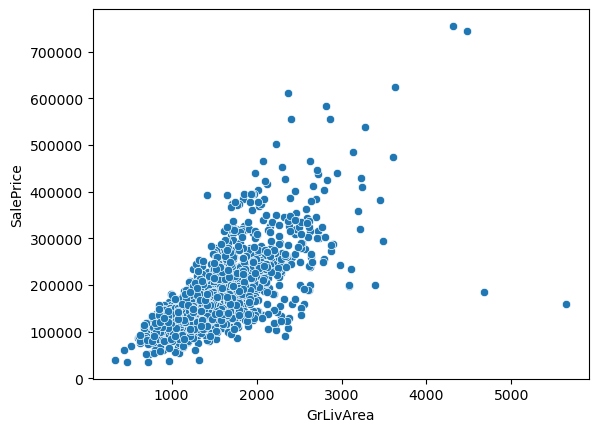

In [27]:
import seaborn as sns

sns.scatterplot(x=train["GrLivArea"], y=train["SalePrice"])

##### Outlier Visualization

##### We created a scatter plot to visualize the relationship between living area and sale price in order to identify possible outliers.

In [28]:
train = train[train["GrLivArea"] < 4000]

##### Removing Outliers

##### We removed houses with extremely large living areas because they may negatively affect the model performance.

In [29]:
import numpy as np

train["SalePrice"] = np.log1p(train["SalePrice"])

##### Log Transformation

##### We applied a logarithmic transformation to the SalePrice feature because the distribution was right-skewed. This helps normalize the data for better model performance.

In [30]:
corr = train.select_dtypes(include=['number']).corr()

##### Correlation Analysis

##### We calculated the correlation matrix for numerical features to identify the variables most strongly related to SalePrice.

<Axes: >

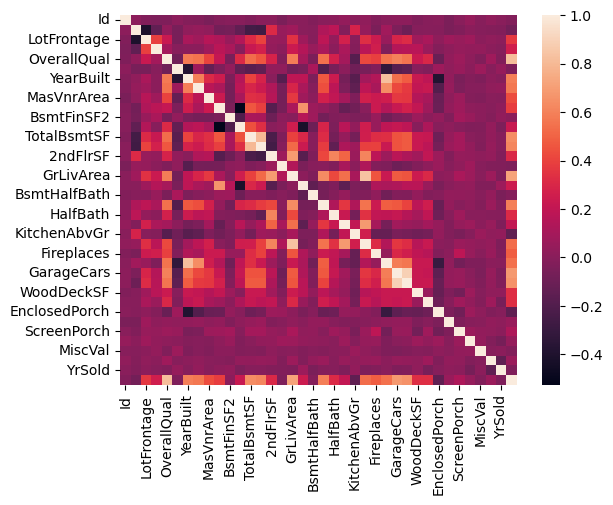

In [31]:
sns.heatmap(corr)

##### Heatmap Visualization

##### We used a heatmap to visualize the correlations between numerical features in the dataset.

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

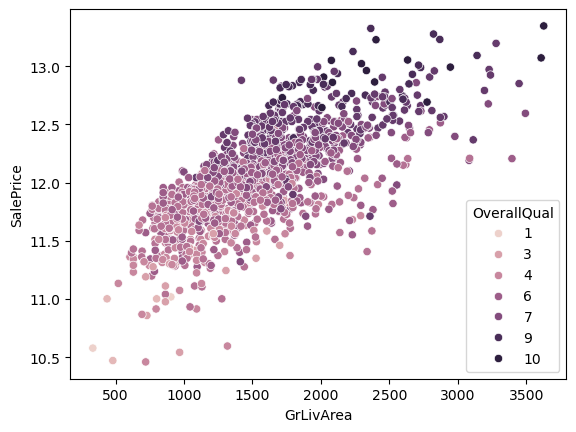

In [32]:
sns.scatterplot(
    x=train["GrLivArea"],
    y=train["SalePrice"],
    hue=train["OverallQual"]
)

##### Relationship Between Features

##### This scatter plot shows the relationship between GrLivArea and SalePrice, with colors representing the overall quality of the house.

In [33]:
train.groupby("Neighborhood")["SalePrice"].mean()

Neighborhood
Blmngtn    12.169421
Blueste    11.826543
BrDale     11.547874
BrkSide    11.679736
ClearCr    12.239905
CollgCr    12.163647
Crawfor    12.206664
Edwards    11.705330
Gilbert    12.155809
IDOTRR     11.446901
MeadowV    11.474533
Mitchel    11.933954
NAmes      11.868052
NPkVill    11.866484
NWAmes     12.130614
NoRidge    12.632321
NridgHt    12.619415
OldTown    11.703873
SWISU      11.838442
Sawyer     11.811475
SawyerW    12.090695
Somerst    12.296500
StoneBr    12.585490
Timber     12.363460
Veenker    12.344180
Name: SalePrice, dtype: float64

##### Neighborhood Analysis

##### We analyzed the average sale price across different neighborhoods to explore geographical trends in housing prices.

In [34]:
train["TotalSF"] = train["TotalBsmtSF"] + train["1stFlrSF"] + train["2ndFlrSF"]

##### Feature Engineering

##### We created a new feature called TotalSF by combining basement, first floor, and second floor areas to represent the total square footage of the house.

In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train["ExterQual"] = le.fit_transform(train["ExterQual"])


##### Label Encoding

##### We applied Label Encoding to ordinal categorical features to preserve the ranking order between categories.

In [36]:
train = pd.get_dummies(train, columns=["Neighborhood"])

##### One-Hot Encoding

##### We applied One-Hot Encoding to nominal categorical variables such as Neighborhood because these categories do not have a natural order.

In [37]:
from sklearn.pipeline import Pipeline

##### Pipeline Preparation

##### We imported Pipeline from scikit-learn to prepare reusable preprocessing steps that can be applied consistently to both training and testing datasets.